In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import re

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import f1_score, matthews_corrcoef, precision_score, recall_score, accuracy_score

# RQ1

## Without Message

### OpenAI/GPT-OSS-20B

Accuracy: 0.6626984126984127
Precision: 0.6147978642257819
Recall: 0.8995535714285714
F1 score: 0.7304032623470775
MCC: 0.36362827035994505
              precision    recall  f1-score   support

       Buggy       0.61      0.90      0.73       896
    NotBuggy       0.80      0.42      0.55       868

    accuracy                           0.66      1764
   macro avg       0.71      0.66      0.64      1764
weighted avg       0.71      0.66      0.64      1764



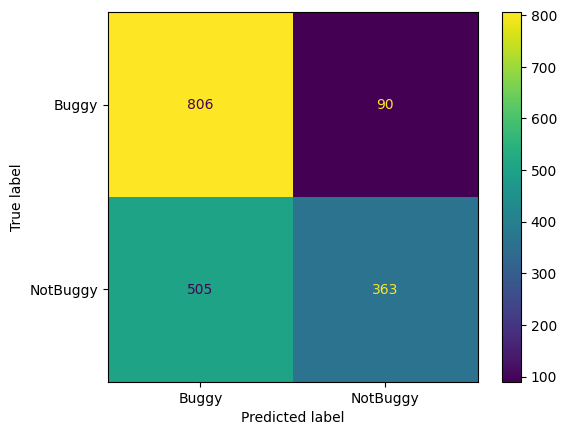

In [9]:
result = pd.read_csv("./Results/RQ1/WithoutMsg/openai-gpt-oss-20b.csv")
result["Output"] = result["Detection"]
            
def extract_result_for_gptoss(text):
    first_word = text
    if "assistantfinal" in text:
        pattern = r"\bassistantfinal\w*"
        first_word = re.findall(pattern, text)[0].replace("assistantfinal", "")
        if first_word == "Bug":
            first_word = "Buggy"
        elif first_word == "NotBug":
            first_word = "NotBuggy"
    else:
        return None
        
    return first_word if len(first_word) > 0 else None
result["Detection"] = result["Detection"].apply(lambda x: extract_result_for_gptoss(x))
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

## With Message

### OpenAI/GPT-OSS-20B

Accuracy: 0.8202947845804989
Precision: 0.7577916295636687
Recall: 0.9497767857142857
F1 score: 0.8429915799900941
MCC: 0.6615060689536474
              precision    recall  f1-score   support

       Buggy       0.76      0.95      0.84       896
    NotBuggy       0.93      0.69      0.79       868

    accuracy                           0.82      1764
   macro avg       0.84      0.82      0.82      1764
weighted avg       0.84      0.82      0.82      1764



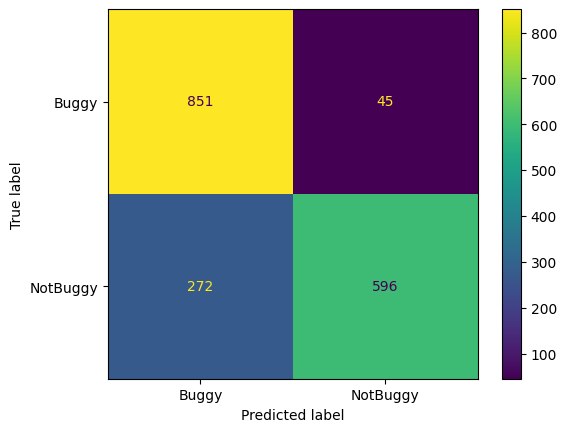

In [44]:
result = pd.read_csv("./Results/RQ1/WithMsg/openai-gpt-oss-20b.csv")
result["Explanation"] = result["Detection"]
            
def extract_result_for_gptoss(text):
    first_word = text
    if "assistantfinal" in text:
        pattern = r"\bassistantfinal\w*"
        first_word = re.findall(pattern, text)[0].replace("assistantfinal", "")
        if first_word == "Bug":
            first_word = "Buggy"
        elif first_word == "NotBug":
            first_word = "NotBuggy"
    else:
        return None
        
    return first_word if len(first_word) > 0 else None

result["Detection"] = result["Detection"].apply(lambda x: extract_result_for_gptoss(x))
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

# RQ2

## FewShot

### OpenAI/GPT-OSS-20B

Accuracy: 0.8373015873015873
Precision: 0.7750677506775068
Recall: 0.9575892857142857
F1 score: 0.8567149276085871
MCC: 0.6935863278030366
              precision    recall  f1-score   support

       Buggy       0.78      0.96      0.86       896
    NotBuggy       0.94      0.71      0.81       868

    accuracy                           0.84      1764
   macro avg       0.86      0.84      0.83      1764
weighted avg       0.86      0.84      0.83      1764



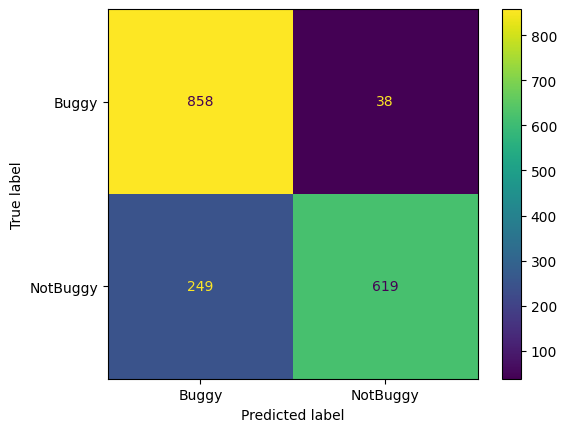

In [18]:
result = pd.read_csv("./Results/RQ2/FewShot/openai-gpt-oss-20b.csv")
result["Explanation"] = result["Detection"]
            
def extract_result_for_gptoss(text):
    first_word = text
    if "assistantfinal" in text or "final" in text:
        pattern = r"assistantfinal\w*"
        words = re.findall(pattern, text)
        if len(words) == 0:
            pattern = r"final:\s*(.+)$"
            words = re.findall(pattern, text)
            if len(words) == 0:
                return text
        first_word = words[0].replace("assistantfinal", "")
        if first_word == "Bug":
            first_word = "Buggy"
        elif first_word == "NotBug":
            first_word = "NotBuggy"
    else:
        return text
        
    return first_word if len(first_word) > 0 else None

result["Detection"] = result["Detection"].apply(lambda x: extract_result_for_gptoss(x))
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()